In [39]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import sklearn as skl
import torch 


In [40]:
#Data generation 
n_samples = 10000
np.random.seed(42)
S0 = np.random.uniform(25,175,n_samples)
K =np.random.uniform(S0*0.75,S0*1.25,n_samples)
T = np.random.uniform(0.1,2,n_samples)
r = np.random.uniform(0.01,0.15,n_samples)
sigma = np.random.uniform(0.05,0.4,n_samples)
#continue from here generate data for k,T,r,sigma 
df = pd.DataFrame({'S0': S0, 'K': K, 'T': T, 'r': r, 'sigma': sigma})
print(df.head(10))
print(df.shape)
print(df.describe())


           S0           K         T         r     sigma
0   81.181018   76.052034  1.486997  0.099340  0.154619
1  167.607146  153.604583  0.450573  0.074301  0.083186
2  134.799091  112.972012  0.758615  0.145030  0.094226
3  114.798773  120.955814  1.360233  0.040657  0.113235
4   48.402796   47.837068  1.015970  0.092300  0.121279
5   48.399178   57.248992  1.503285  0.108029  0.134792
6   33.712542   25.825654  1.926295  0.125579  0.139411
7  154.926422  166.070893  0.321439  0.066976  0.209501
8  115.167252  130.308802  1.448179  0.106169  0.228351
9  131.210887  148.234618  0.537654  0.052448  0.158108
(10000, 5)
                 S0             K             T             r         sigma
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000
mean      99.123934     99.316460      1.050096      0.079820      0.223902
std       43.144519     45.939587      0.544870      0.040459      0.101249
min       25.001745     19.144947      0.100091      0.010001      0.

In [41]:
#CRR pricing 
def crr_put_price(S0,K,T,r,sigma,steps,american=True):
    if steps <= 0:
        raise ValueError("steps must be positive")
    if T <= 0:
        # At maturity, option is just intrinsic value
        return max(K - S0, 0.0)
    if sigma <= 0:
        # Degenerate case not central here, but let's handle gracefully
        # Under deterministic growth S_T = S0*exp(rT)
        ST = S0 * np.exp(r * T)
        euro = np.exp(-r*T) * max(K - ST, 0.0)
        if american:
            return max(euro, max(K - S0, 0.0))
        return euro

    dt = T / steps
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    disc = np.exp(-r * dt)
    p = (np.exp(r * dt) - d) / (u - d)

    if not (0 < p < 1):
        raise ValueError("Risk-neutral probability out of bounds. Try more steps or check parameters.")

    # Terminal stock prices at time T
    j = np.arange(steps + 1)  # number of up moves
    ST = S0 * (u ** j) * (d ** (steps - j))

    # Terminal put payoffs
    option_values = np.maximum(K - ST, 0.0)

    # Backward induction
    for i in range(steps - 1, -1, -1):
        # continuation values at time i
        option_values = disc * (p * option_values[1:i+2] + (1 - p) * option_values[0:i+1])

        if american:
            # stock prices at time i
            j = np.arange(i + 1)
            S_i = S0 * (u ** j) * (d ** (i - j))
            exercise = np.maximum(K - S_i, 0.0)
            option_values = np.maximum(option_values, exercise)

    return float(option_values[0])

In [42]:
prices = []

for i in range(len(df)):
    price = crr_put_price(df['S0'][i], df['K'][i], df['T'][i], df['r'][i], df['sigma'][i], steps=100, american=True)
    prices.append(price)

df['Price'] = prices
print(df.head(10))

           S0           K         T         r     sigma      Price
0   81.181018   76.052034  1.486997  0.099340  0.154619   1.340759
1  167.607146  153.604583  0.450573  0.074301  0.083186   0.054940
2  134.799091  112.972012  0.758615  0.145030  0.094226   0.000811
3  114.798773  120.955814  1.360233  0.040657  0.113235   7.348272
4   48.402796   47.837068  1.015970  0.092300  0.121279   0.937884
5   48.399178   57.248992  1.503285  0.108029  0.134792   8.849814
6   33.712542   25.825654  1.926295  0.125579  0.139411   0.011030
7  154.926422  166.070893  0.321439  0.066976  0.209501  12.803567
8  115.167252  130.308802  1.448179  0.106169  0.228351  16.138848
9  131.210887  148.234618  0.537654  0.052448  0.158108  17.023731


In [43]:
df.to_csv('data6.csv', index=False)

In [44]:
# Train / Validation / Test Split

from sklearn.model_selection import train_test_split

X = df[["S0", "K", "T", "r", "sigma"]]
y = df["Price"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Training: (8000, 5) (8000,)
Validation: (1000, 5) (1000,)
Test: (1000, 5) (1000,)


In [45]:
# Standardize the FEATURES only

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

# IMPORTANT:
# Do NOT call fit() again.
# Reuse the same mean and std from the training set.

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
# Check that standardization worked

# Reshape targets

y_train = y_train.to_numpy().reshape(-1, 1)
y_val = y_val.to_numpy().reshape(-1, 1)
y_test = y_test.to_numpy().reshape(-1, 1)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)


(8000, 1)
(1000, 1)
(1000, 1)


In [46]:
#PYTORCH !!
# Convert everything to PyTorch tensors

X_train_tensor = torch.from_numpy(X_train).float()
X_val_tensor = torch.from_numpy(X_val).float()
X_test_tensor = torch.from_numpy(X_test).float()

y_train_tensor = torch.from_numpy(y_train).float()
y_val_tensor = torch.from_numpy(y_val).float()
y_test_tensor = torch.from_numpy(y_test).float()
print(X_train_tensor.shape, y_train_tensor.shape)

torch.Size([8000, 5]) torch.Size([8000, 1])


In [47]:
import torch.nn as nn 
import torch.optim 

class OptionPricer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 16)
        self.fc3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
model = OptionPricer(input_dim=5)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
#TRAINING LOOP
for epoch in range(500):
    optimizer.zero_grad()
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss = {loss.item():.6f}")
    model.eval()

    with torch.no_grad():
        val_predictions = model(X_val_tensor)
        val_loss = criterion(val_predictions, y_val_tensor)
        print(f"Validation Loss = {val_loss.item():.4f}")

Epoch 1, Loss = 174.940704
tensor(183.1731)
Epoch 2, Loss = 174.561264
tensor(182.7959)
Epoch 3, Loss = 174.194153
tensor(182.4286)
Epoch 4, Loss = 173.837540
tensor(182.0701)
Epoch 5, Loss = 173.489456
tensor(181.7172)
Epoch 6, Loss = 173.147736
tensor(181.3691)
Epoch 7, Loss = 172.810608
tensor(181.0242)
Epoch 8, Loss = 172.477722
tensor(180.6815)
Epoch 9, Loss = 172.147644
tensor(180.3404)
Epoch 10, Loss = 171.820114
tensor(180.0013)
Epoch 11, Loss = 171.493881
tensor(179.6639)
Epoch 12, Loss = 171.168655
tensor(179.3254)
Epoch 13, Loss = 170.843277
tensor(178.9860)
Epoch 14, Loss = 170.517166
tensor(178.6454)
Epoch 15, Loss = 170.189590
tensor(178.3020)
Epoch 16, Loss = 169.860123
tensor(177.9559)
Epoch 17, Loss = 169.527832
tensor(177.6055)
Epoch 18, Loss = 169.191574
tensor(177.2502)
Epoch 19, Loss = 168.850372
tensor(176.8895)
Epoch 20, Loss = 168.503876
tensor(176.5227)
Epoch 21, Loss = 168.151764
tensor(176.1495)
Epoch 22, Loss = 167.793335
tensor(175.7694)
Epoch 23, Loss = 16

In [50]:
print(df["Price"].describe())
train_rmse = loss.item() ** 0.5
val_rmse = val_loss.item() ** 0.5

print(train_rmse)
print(val_rmse)

count    10000.000000
mean         8.975104
std          9.524277
min          0.000000
25%          1.428888
50%          5.747631
75%         13.568289
max         51.217559
Name: Price, dtype: float64
2.6813122686522632
2.7260312325192033


In [51]:
pred = model(X_test_tensor)
print(pred[:10])
print(y_test_tensor[:10])
mae = torch.mean(torch.abs(pred - y_test_tensor))
print("MAE =", mae.item())

tensor([[31.0414],
        [ 8.4341],
        [ 6.2145],
        [ 2.1307],
        [14.8422],
        [ 8.5225],
        [ 7.8435],
        [ 5.9598],
        [22.9945],
        [13.2429]], grad_fn=<SliceBackward0>)
tensor([[33.9652],
        [ 5.1421],
        [ 5.2451],
        [ 0.3579],
        [15.2171],
        [ 7.9380],
        [ 8.4294],
        [ 5.4243],
        [21.1412],
        [14.5502]])
MAE = 2.0614354610443115


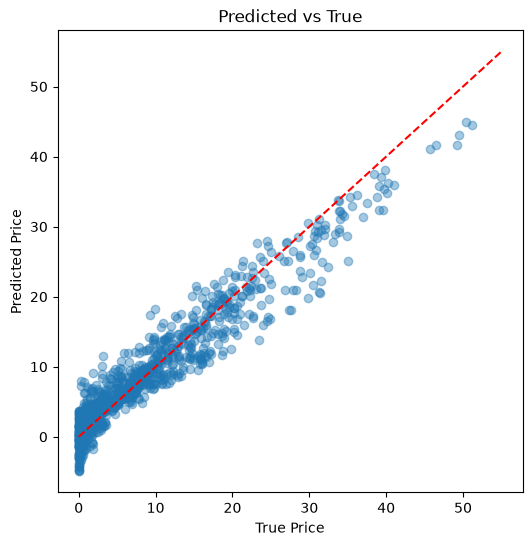

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_tensor.numpy(),
            pred.detach().numpy(),
            alpha=0.4)

plt.plot([0,55],[0,55],'r--')
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs True")
plt.show()

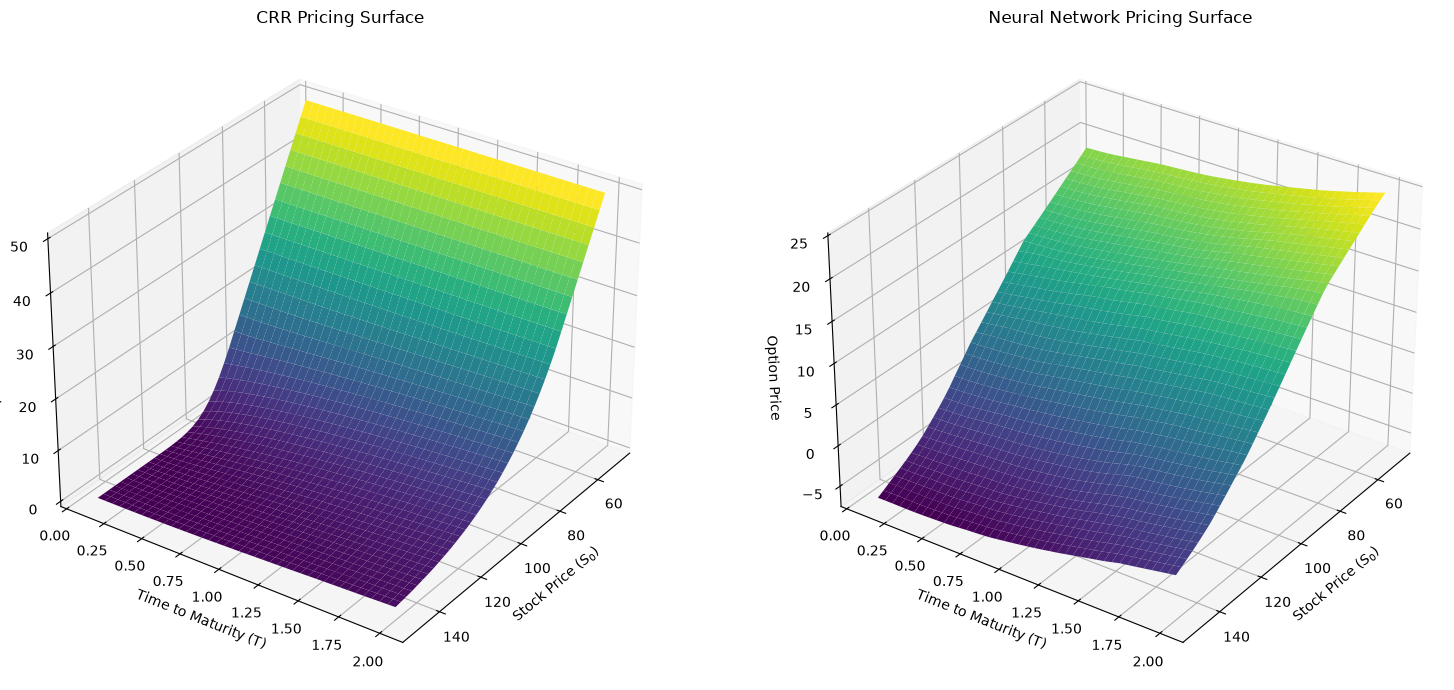

In [56]:
# --------------------------
# Fixed Parameters
# --------------------------

K = 100
r = 0.05
sigma = 0.25
steps = 100

S0 = np.linspace(50,150,40)
T = np.linspace(0.1,2.0,40)

S0_grid, T_grid = np.meshgrid(S0,T)

prices_nn = np.zeros_like(S0_grid)
prices_crr = np.zeros_like(S0_grid)

# --------------------------
# Compute Prices
# --------------------------

for i in range(S0_grid.shape[0]):
    for j in range(S0_grid.shape[1]):

        # CRR Price
        prices_crr[i,j] = crr_put_price(
            S0=S0_grid[i,j],
            K=K,
            r=r,
            sigma=sigma,
            T=T_grid[i,j],
            steps=steps,
            american=True
        )

        # Neural Network Input

        x = pd.DataFrame(
            [[S0_grid[i,j],K,T_grid[i,j],r,sigma]],
            columns=["S0","K","T","r","sigma"]
        )

        x_scaled = scaler.transform(x)

        x_tensor = torch.tensor(
            x_scaled,
            dtype=torch.float32
        )

        with torch.no_grad():
            prices_nn[i,j] = model(x_tensor).item()

# --------------------------
# Plot
# --------------------------

fig = plt.figure(figsize=(16,7))

# Left Plot

ax1 = fig.add_subplot(121, projection='3d')

surf1 = ax1.plot_surface(
    S0_grid,
    T_grid,
    prices_crr,
    cmap='viridis',
    edgecolor='none'
)

ax1.set_title("CRR Pricing Surface")

ax1.set_xlabel("Stock Price ($S_0$)")
ax1.set_ylabel("Time to Maturity (T)")
ax1.set_zlabel("Option Price")

ax1.view_init(elev=30, azim=35)

# Right Plot

ax2 = fig.add_subplot(122, projection='3d')

surf2 = ax2.plot_surface(
    S0_grid,
    T_grid,
    prices_nn,
    cmap='viridis',
    edgecolor='none'
)

ax2.set_title("Neural Network Pricing Surface")

ax2.set_xlabel("Stock Price ($S_0$)")
ax2.set_ylabel("Time to Maturity (T)")
ax2.set_zlabel("Option Price")

ax2.view_init(elev=30, azim=35)

plt.tight_layout()

plt.savefig(
    "pricing_surfaces.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

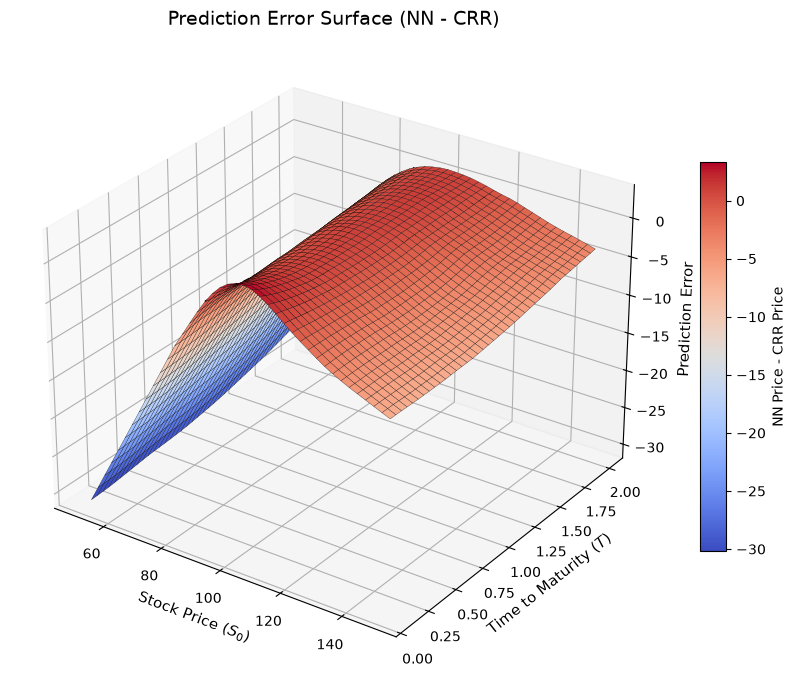

In [57]:


# Error
error = prices_nn - prices_crr

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    S0_grid,
    T_grid,
    error,
    cmap='coolwarm',      # Blue = Negative, Red = Positive
    edgecolor='black',
    linewidth=0.2,
    antialiased=True
)

ax.set_title("Prediction Error Surface (NN - CRR)", fontsize=14)

ax.set_xlabel("Stock Price ($S_0$)", fontsize=11)
ax.set_ylabel("Time to Maturity ($T$)", fontsize=11)
ax.set_zlabel("Prediction Error", fontsize=11)

# Same view as your previous plots
ax.view_init(elev=28, azim=-55)

# Horizontal plane at zero error
ax.contour(
    S0_grid,
    T_grid,
    error,
    levels=[0],
    colors='black',
    linestyles='dashed',
    offset=0
)

fig.colorbar(
    surf,
    shrink=0.6,
    aspect=15,
    label="NN Price - CRR Price"
)

plt.tight_layout()

plt.savefig(
    "error_surface.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
model.eval()

with torch.no_grad():
    pred = model(X_test_tensor)

print(pred.min())
print(pred.max())

tensor(-4.9557)
tensor(44.9070)
